In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

# Load data
df = pd.read_csv('../data/dataset.csv')

print(df.shape)
print(df.dtypes)
df.head()

(114000, 21)
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [2]:
# Drop duplicates and nulls
df = df.drop_duplicates()
df = df.dropna()

# Drop the unnamed index column
df = df.drop(columns=['Unnamed: 0'])

# Convert duration from ms to seconds
df['duration_s'] = df['duration_ms'] / 1000

# Extract release year and create decade
df['release_year'] = pd.to_datetime(df['album_name'], errors='coerce')
df['release_year'] = pd.to_numeric(df['track_id'].apply(lambda x: None), errors='coerce')

# Better approach - just use a decade bucket from the data we have
# Let's check what date columns exist
print(df.columns.tolist())
print(df.shape)

/var/folders/vm/fvggmyls2d963zddwmvtffm00000gn/T/ipykernel_74747/2264908968.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['release_year'] = pd.to_datetime(df['album_name'], errors='coerce')


['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'duration_s', 'release_year']
(113999, 22)


In [3]:
# Summary stats for audio features
audio_features = ['popularity', 'danceability', 'energy', 'loudness', 
                  'speechiness', 'acousticness', 'valence', 'tempo']

df[audio_features].describe().round(2)

,popularity,danceability,energy,loudness,speechiness,acousticness,valence,tempo
count,113999.00,113999.00,113999.00,113999.00,113999.00,113999.00,113999.00,113999.00
mean,33.24,0.57,0.64,-8.26,0.08,0.31,0.47,122.15
std,22.30,0.17,0.25,5.03,0.11,0.33,0.26,29.98
min,0.00,0.00,0.00,-49.53,0.00,0.00,0.00,0.00
25%,17.00,0.46,0.47,-10.01,0.04,0.02,0.26,99.22
50%,35.00,0.58,0.68,-7.00,0.05,0.17,0.46,122.02
75%,50.00,0.70,0.85,-5.00,0.08,0.60,0.68,140.07
max,100.00,0.98,1.00,4.53,0.96,1.00,1.00,243.37


In [4]:
print(f"Unique genres: {df['track_genre'].nunique()}")
print(df['track_genre'].value_counts().head(20))

Unique genres: 114
track_genre
acoustic             1000
afrobeat             1000
psych-rock           1000
progressive-house    1000
power-pop            1000
pop                  1000
pop-film             1000
piano                1000
party                1000
pagode               1000
opera                1000
new-age              1000
mpb                  1000
minimal-techno       1000
metalcore            1000
metal                1000
mandopop             1000
malay                1000
latino               1000
latin                1000
Name: count, dtype: int64


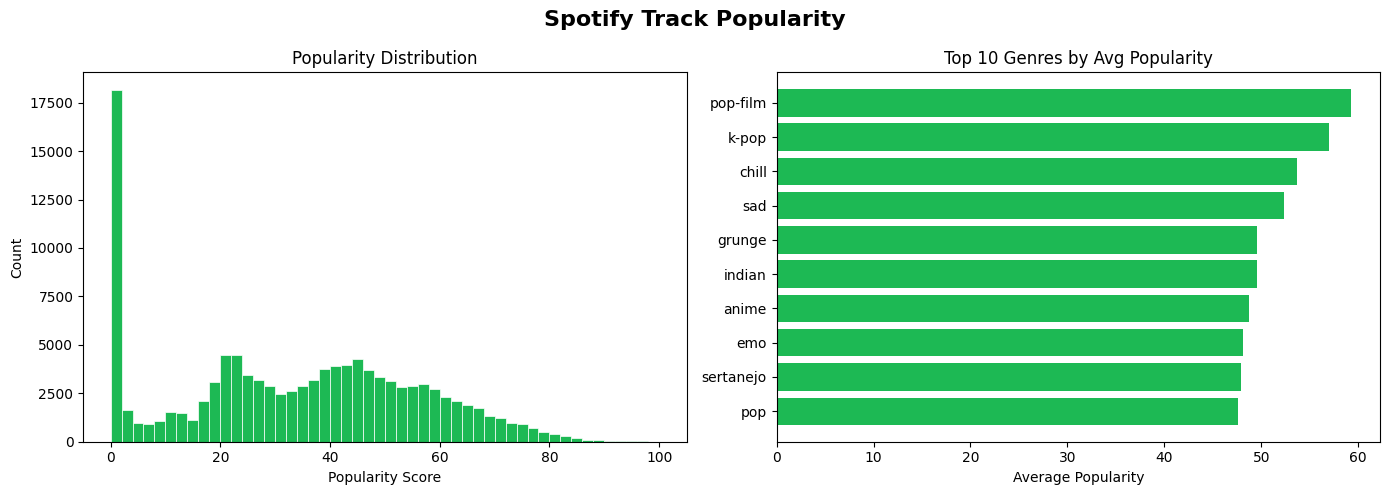

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Spotify Track Popularity', fontsize=16, fontweight='bold')

# Distribution
axes[0].hist(df['popularity'], bins=50, color='#1DB954', edgecolor='white', linewidth=0.5)
axes[0].set_title('Popularity Distribution')
axes[0].set_xlabel('Popularity Score')
axes[0].set_ylabel('Count')

# Top 10 genres by avg popularity
top_genres = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)
axes[1].barh(top_genres.index, top_genres.values, color='#1DB954')
axes[1].set_title('Top 10 Genres by Avg Popularity')
axes[1].set_xlabel('Average Popularity')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../data/popularity.png', dpi=150, bbox_inches='tight')
plt.show()

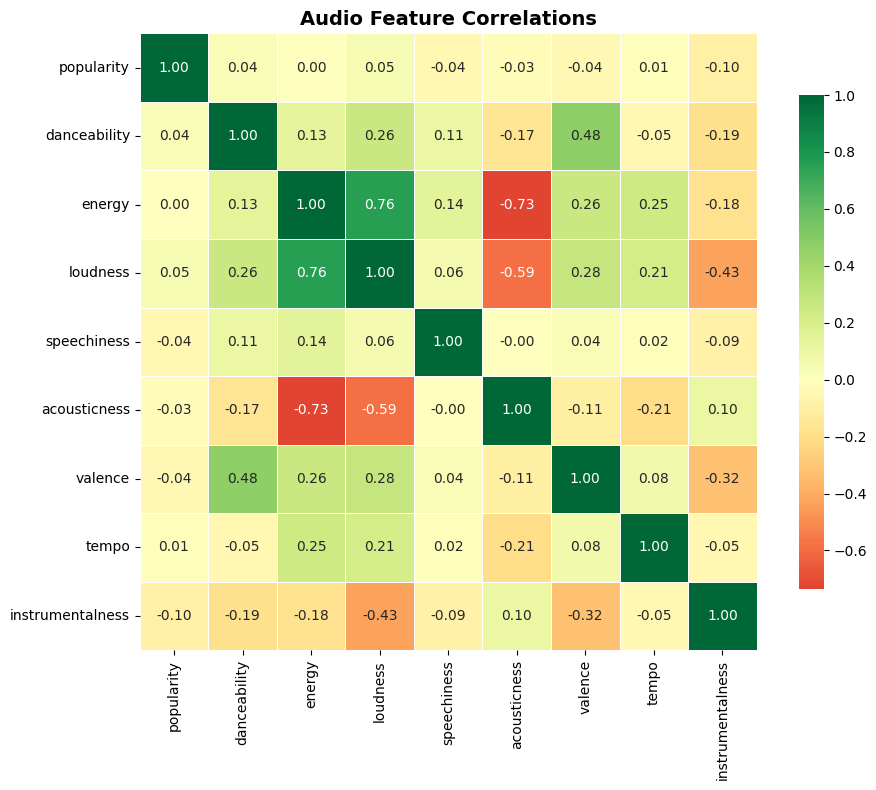

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

audio_features = ['popularity', 'danceability', 'energy', 'loudness',
                  'speechiness', 'acousticness', 'valence', 'tempo', 'instrumentalness']

corr = df[audio_features].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})

ax.set_title('Audio Feature Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/correlations.png', dpi=150, bbox_inches='tight')
plt.show()

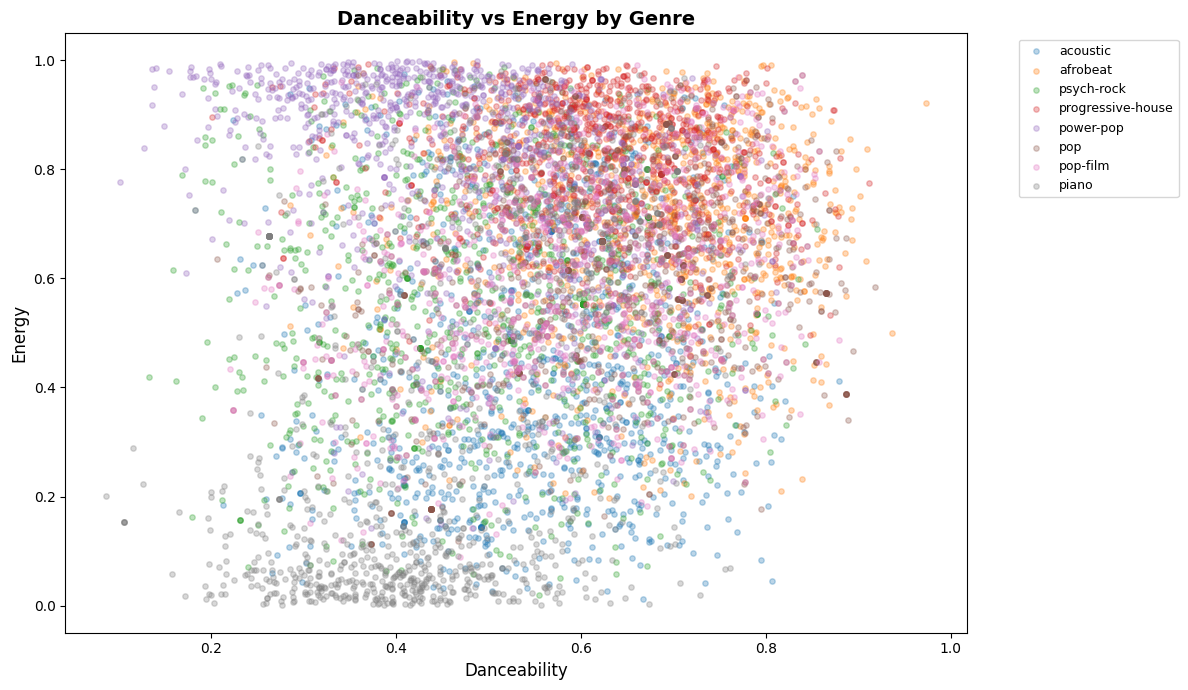

In [7]:
# Pick top 8 genres for clarity
top8 = df['track_genre'].value_counts().head(8).index
df_top8 = df[df['track_genre'].isin(top8)]

fig, ax = plt.subplots(figsize=(12, 7))

for genre in top8:
    subset = df_top8[df_top8['track_genre'] == genre]
    ax.scatter(subset['danceability'], subset['energy'],
               alpha=0.3, s=15, label=genre)

ax.set_xlabel('Danceability', fontsize=12)
ax.set_ylabel('Energy', fontsize=12)
ax.set_title('Danceability vs Energy by Genre', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../data/dance_energy.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
import duckdb

con = duckdb.connect()
con.register('spotify', df)

print("DuckDB ready!")

DuckDB ready!


In [9]:
result = con.execute("""
    SELECT 
        track_genre,
        ROUND(AVG(danceability), 3) AS avg_danceability,
        ROUND(AVG(energy), 3) AS avg_energy,
        ROUND(AVG(valence), 3) AS avg_valence,
        COUNT(*) AS track_count
    FROM spotify
    GROUP BY track_genre
    ORDER BY avg_danceability DESC
    LIMIT 10
""").df()

result

,track_genre,avg_danceability,avg_energy,avg_valence,track_count
0,kids,0.779,0.613,0.681,1000
1,chicago-house,0.766,0.733,0.587,1000
2,reggaeton,0.759,0.739,0.643,1000
3,latino,0.757,0.732,0.630,1000
4,reggae,0.745,0.726,0.648,1000
5,hip-hop,0.736,0.683,0.551,1000
6,dancehall,0.734,0.685,0.629,1000
7,minimal-techno,0.729,0.680,0.284,1000
8,detroit-techno,0.723,0.711,0.469,1000
9,latin,0.722,0.727,0.631,1000


In [10]:
result2 = con.execute("""
    SELECT
        track_genre,
        ROUND(AVG(loudness), 2) AS avg_loudness,
        ROUND(AVG(popularity), 2) AS avg_popularity,
        ROUND(AVG(tempo), 1) AS avg_tempo
    FROM spotify
    GROUP BY track_genre
    ORDER BY avg_popularity DESC
    LIMIT 15
""").df()

result2

,track_genre,avg_loudness,avg_popularity,avg_tempo
0,pop-film,-7.87,59.28,117.3
1,k-pop,-6.47,56.95,119.2
2,chill,-10.46,53.65,115.5
3,sad,-10.28,52.38,119.1
4,grunge,-5.66,49.59,129.3
5,indian,-8.85,49.54,116.1
6,anime,-7.93,48.77,123.5
7,emo,-6.72,48.13,127.0
8,sertanejo,-5.49,47.87,127.1
9,pop,-6.95,47.58,120.9


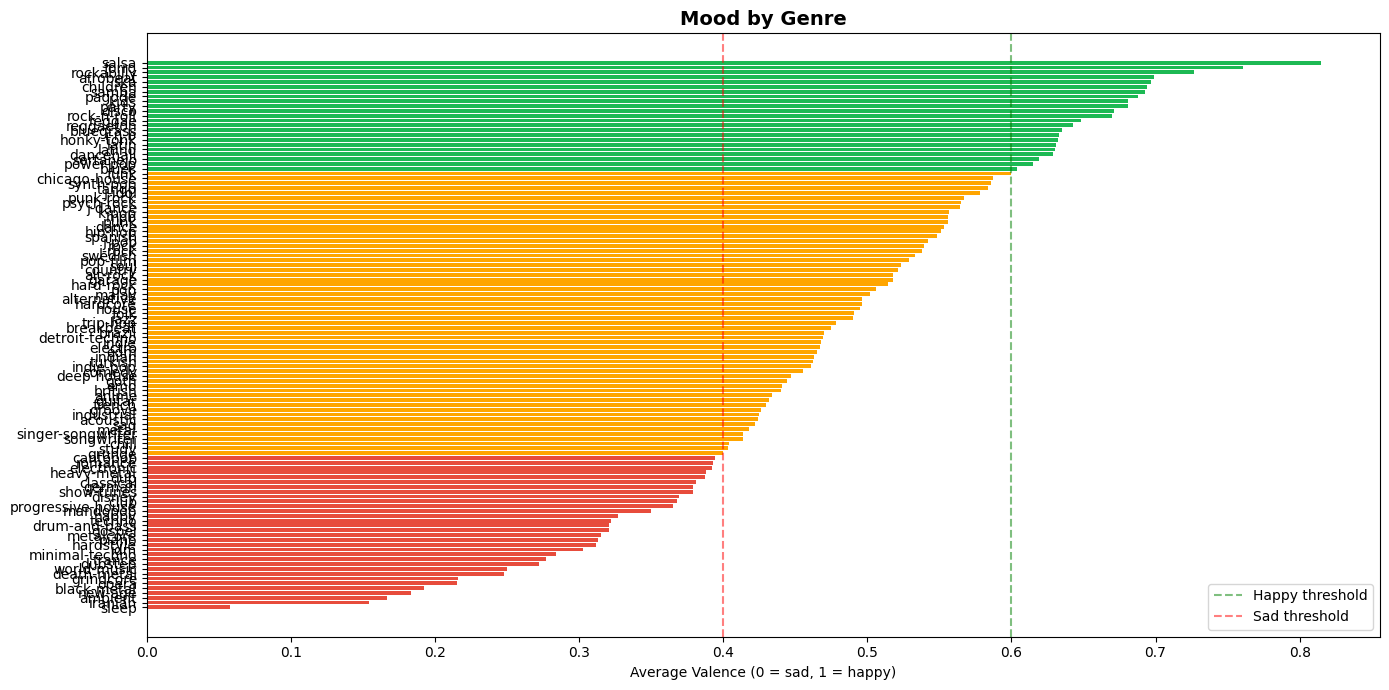

In [11]:
result3 = con.execute("""
    SELECT
        track_genre,
        ROUND(AVG(valence), 3) AS avg_valence,
        CASE 
            WHEN AVG(valence) > 0.6 THEN 'Happy'
            WHEN AVG(valence) > 0.4 THEN 'Neutral'
            ELSE 'Sad'
        END AS mood
    FROM spotify
    GROUP BY track_genre
    ORDER BY avg_valence DESC
""").df()

# Plot it
fig, ax = plt.subplots(figsize=(14, 7))
colors = result3['mood'].map({'Happy': '#1DB954', 'Neutral': '#FFA500', 'Sad': '#E74C3C'})
ax.barh(result3['track_genre'], result3['avg_valence'], color=colors)
ax.axvline(x=0.6, color='green', linestyle='--', alpha=0.5, label='Happy threshold')
ax.axvline(x=0.4, color='red', linestyle='--', alpha=0.5, label='Sad threshold')
ax.set_xlabel('Average Valence (0 = sad, 1 = happy)')
ax.set_title('Mood by Genre', fontsize=14, fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../data/mood_genre.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
result4 = con.execute("""
    SELECT
        track_name,
        artists,
        track_genre,
        popularity,
        ROUND(danceability, 2) AS danceability,
        ROUND(energy, 2) AS energy,
        ROUND(valence, 2) AS valence
    FROM spotify
    ORDER BY popularity DESC
    LIMIT 10
""").df()

result4

,track_name,artists,track_genre,popularity,danceability,energy,valence
0,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,pop,100,0.71,0.47,0.24
1,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,dance,100,0.71,0.47,0.24
2,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,hip-hop,99,0.62,0.78,0.55
3,I'm Good (Blue),David Guetta;Bebe Rexha,dance,98,0.56,0.97,0.30
4,I'm Good (Blue),David Guetta;Bebe Rexha,pop,98,0.56,0.97,0.30
5,I'm Good (Blue),David Guetta;Bebe Rexha,edm,98,0.56,0.97,0.30
6,La Bachata,Manuel Turizo,latin,98,0.84,0.68,0.85
7,La Bachata,Manuel Turizo,latino,98,0.84,0.68,0.85
8,La Bachata,Manuel Turizo,reggae,98,0.84,0.68,0.85
9,La Bachata,Manuel Turizo,reggaeton,98,0.84,0.68,0.85
